# Depth-edge analysis
Post-analysis for raw outputs from the YOLO + FoundationStereo pipeline.

Inputs expected in the selected run's `raw/` folder:
- depth.npy (float32 meters) or depth.exr (value in RED channel)
- edges.npy (uint8) or edges.png (uint8)

This notebook breaks the workflow into clear steps and displays results inline. It does not write any files to disk.

In [104]:
# Imports
import os, json
import numpy as np
import cv2
import imageio
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (10,6)

In [105]:
# Parameters
# Set raw_dir to the path of a run's raw/ folder. Use a raw string on Windows, e.g., r'C\\path\\to\\run\\raw'
# If left as None, the next cell will try to auto-detect a suitable raw/ folder.
raw_dir = None  # e.g., r'C:\\Users\\1213123\\Documents\\Scripts\\FoundationStereo\\scripts\\unity_yolo\\output_3d_blocks\\your_run\\raw'

buffer_px = 6
roi_margin_px = 8
method = 'canny'  # 'sobel' | 'laplacian' | 'canny'
edge_thresh = None  # absolute threshold for sobel/laplacian (meters/pixel); if None uses percentile
edge_percentile = 95.0
flatten_far_m = 5.0  # if depth > T meters, set to T to reduce sky/background artifacts
max_edge_dist_px = 2.0  # maximum allowed distance from loaded edge to keep a depth edge

# Roots to search for runs if raw_dir is None or invalid (relative to this notebook location)
search_roots = [
    r'./output_3d_blocks',
    r'../output_3d_blocks',
    r'../../scripts/unity_yolo/output_3d_blocks',
    r'./scripts/unity_yolo/output_3d_blocks',
]

print('Initial raw_dir:', raw_dir)
print('buffer_px =', buffer_px)
print('roi_margin_px =', roi_margin_px)
print('method =', method)
print('edge_thresh =', edge_thresh, 'edge_percentile =', edge_percentile)
print('flatten_far_m =', flatten_far_m)
print('max_edge_dist_px =', max_edge_dist_px)

Initial raw_dir: None
buffer_px = 6
roi_margin_px = 8
method = canny
edge_thresh = None edge_percentile = 95.0
flatten_far_m = 5.0
max_edge_dist_px = 2.0


In [106]:
# Auto-detect and validate raw_dir
import time

def has_required_files(run_dir: str) -> bool:
    d_npy = os.path.join(run_dir, 'depth.npy')
    d_exr = os.path.join(run_dir, 'depth.exr')
    e_npy = os.path.join(run_dir, 'edges.npy')
    e_png = os.path.join(run_dir, 'edges.png')
    return (os.path.isfile(d_npy) or os.path.isfile(d_exr)) and (os.path.isfile(e_npy) or os.path.isfile(e_png))

if raw_dir is None or not os.path.isdir(raw_dir) or not has_required_files(raw_dir):
    print('\nTrying to auto-detect a raw/ folder...')
    candidates = []
    for root in search_roots:
        root_abs = os.path.abspath(root)
        if not os.path.isdir(root_abs):
            continue
        for dirpath, dirnames, filenames in os.walk(root_abs):
            if os.path.basename(dirpath).lower() == 'raw' and has_required_files(dirpath):
                # Score by most recent mtime among contained files
                try:
                    mtimes = [os.path.getmtime(os.path.join(dirpath, f)) for f in filenames]
                    score = max(mtimes) if mtimes else 0
                except Exception:
                    score = 0
                candidates.append((score, dirpath))
    if candidates:
        candidates.sort(reverse=True)
        print('Found candidates:')
        for i, (score, path) in enumerate(candidates[:10], 1):
            ts = time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(score))
            print(f'  {i}. {path}  (latest file: {ts})')
        raw_dir = candidates[0][1]
        print('\nSelected raw_dir =', raw_dir)
    else:
        raise FileNotFoundError('Could not auto-detect a valid raw/ folder. Please set raw_dir to a specific path.')
else:
    print('Using provided raw_dir =', raw_dir)

# Quick peek at files inside raw_dir
try:
    names = os.listdir(raw_dir)
    print('\nraw_dir contents (first 20):')
    for n in names[:20]:
        print(' -', n)
except Exception as e:
    print('Warning: could not list raw_dir:', e)


Trying to auto-detect a raw/ folder...
Found candidates:
  1. c:\Users\1213123\Documents\Scripts\FoundationStereo\scripts\unity_yolo\output_3d_blocks\raw  (latest file: 2025-10-22 21:19:52)

Selected raw_dir = c:\Users\1213123\Documents\Scripts\FoundationStereo\scripts\unity_yolo\output_3d_blocks\raw

raw_dir contents (first 20):
 - 1.exr
 - depth.exr
 - depth.npy
 - depth_mm.png
 - disparity.exr
 - disparity.npy
 - disparity_u16.png
 - edges.npy
 - edges.png
 - meta.json
 - post


In [107]:
# Helpers (ported from analyze_depth_edges.py)
def ensure_dir(path: str):
    os.makedirs(path, exist_ok=True)

def load_raw(raw_dir: str):
    depth_npy = os.path.join(raw_dir, 'depth.npy')
    edges_npy = os.path.join(raw_dir, 'edges.npy')
    depth_exr = os.path.join(raw_dir, 'depth.exr')
    edges_png = os.path.join(raw_dir, 'edges.png')

    if os.path.exists(depth_npy):
        depth = np.load(depth_npy).astype(np.float32)
    elif os.path.exists(depth_exr):
        d = imageio.imread(depth_exr)
        # If 3-channel EXR with value in red channel
        if d.ndim == 3 and d.shape[2] >= 1:
            depth = d[...,0].astype(np.float32)
        else:
            depth = d.astype(np.float32)
    else:
        raise FileNotFoundError('Could not find depth.npy or depth.exr in raw_dir')

    if os.path.exists(edges_npy):
        edges = np.load(edges_npy)
        if edges.dtype != np.uint8:
            edges = edges.astype(np.uint8)
        edges_bin = (edges > 0).astype(np.uint8)
    elif os.path.exists(edges_png):
        e = cv2.imread(edges_png, cv2.IMREAD_GRAYSCALE)
        edges_bin = (e > 0).astype(np.uint8)
    else:
        raise FileNotFoundError('Could not find edges.npy or edges.png in raw_dir')
    return depth, edges_bin

def buffer_edges(edges_bin: np.ndarray, buffer_px: int) -> np.ndarray:
    if buffer_px <= 0:
        return edges_bin.copy()
    k = 2 * buffer_px + 1
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (k, k))
    return cv2.dilate(edges_bin, kernel, iterations=1)

def compute_roi_from_mask(mask: np.ndarray, margin: int = 0):
    ys, xs = np.where(mask > 0)
    if ys.size == 0 or xs.size == 0:
        return None
    y1, y2 = int(ys.min()), int(ys.max())
    x1, x2 = int(xs.min()), int(xs.max())
    if margin > 0:
        y1 -= margin; y2 += margin; x1 -= margin; x2 += margin
    h, w = mask.shape[:2]
    y1 = max(0, y1); x1 = max(0, x1)
    y2 = min(h - 1, y2); x2 = min(w - 1, x2)
    return x1, y1, x2, y2

def visualize_depth(depth: np.ndarray) -> np.ndarray:
    d = depth.copy()
    valid = np.isfinite(d) & (d > 0)
    if not valid.any():
        return np.zeros((*d.shape, 3), dtype=np.uint8)
    dmin = float(np.percentile(d[valid], 5))
    dmax = float(np.percentile(d[valid], 95))
    if dmax <= dmin:
        dmax = dmin + 1e-6
    d_clipped = np.clip(d, dmin, dmax)
    d_norm = (d_clipped - dmin) / (dmax - dmin)
    d_norm[~valid] = 0
    img_u8 = (np.clip(d_norm, 0, 1) * 255).astype(np.uint8)
    color = cv2.applyColorMap(img_u8, cv2.COLORMAP_TURBO)
    color[~valid] = 0
    return color

def fill_invalid_with_median(depth: np.ndarray) -> np.ndarray:
    d = depth.copy()
    valid = np.isfinite(d) & (d > 0)
    if not valid.any():
        return np.nan_to_num(d, nan=0.0, posinf=0.0, neginf=0.0)
    med = float(np.median(d[valid]))
    d[~valid] = med
    return d

def detect_depth_edges(depth_roi: np.ndarray, method: str, edge_thresh: float | None, edge_percentile: float | None):
    d_filled = fill_invalid_with_median(depth_roi.astype(np.float32))
    if method == 'sobel':
        dx = cv2.Sobel(d_filled, cv2.CV_32F, 1, 0, ksize=3)
        dy = cv2.Sobel(d_filled, cv2.CV_32F, 0, 1, ksize=3)
        grad = np.sqrt(dx * dx + dy * dy)
    elif method == 'laplacian':
        grad = cv2.Laplacian(d_filled, cv2.CV_32F, ksize=3)
        grad = np.abs(grad)
    elif method == 'canny':
        valid = np.isfinite(depth_roi) & (depth_roi > 0)
        if valid.any():
            dmin = float(np.percentile(depth_roi[valid], 5))
            dmax = float(np.percentile(depth_roi[valid], 95))
            if dmax <= dmin: dmax = dmin + 1e-6
            d_norm = (np.clip(depth_roi, dmin, dmax) - dmin) / (dmax - dmin)
        else:
            d_norm = np.zeros_like(depth_roi, dtype=np.float32)
        img_u8 = (np.clip(d_norm, 0, 1) * 255).astype(np.uint8)
        if edge_thresh is None and edge_percentile is not None:
            low = int(np.percentile(img_u8, edge_percentile * 0.5))
            high = int(np.percentile(img_u8, edge_percentile))
        else:
            low, high = 50, 150
        edges = cv2.Canny(img_u8, low, high)
        grad = edges.astype(np.float32)
    else:
        raise ValueError('Unknown method. Choose from: sobel, laplacian, canny')

    if method in ('sobel', 'laplacian'):
        if edge_thresh is not None:
            th = float(edge_thresh)
        elif edge_percentile is not None:
            th = float(np.percentile(grad, edge_percentile))
        else:
            th = float(np.percentile(grad, 95))
        edges_bin = (grad >= th).astype(np.uint8) * 255
    else:
        edges_bin = (grad > 0).astype(np.uint8) * 255
    return grad, edges_bin

Depth shape: (400, 650) dtype: float32 min: 0.0 max: 499.84363
Edges shape: (400, 650) dtype: uint8 nonzero: 661


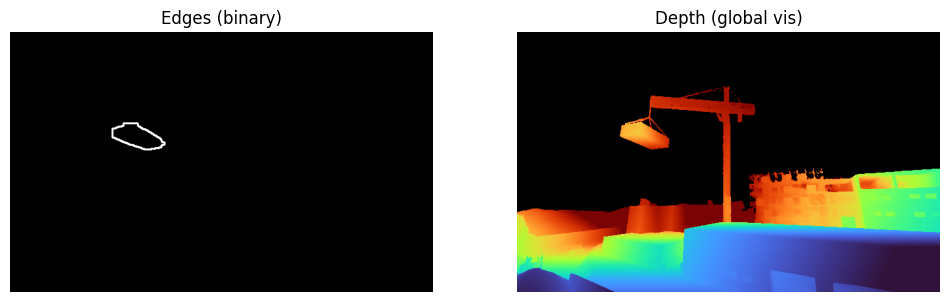

In [108]:
# Step 1: Load raw depth and edges, inspect
depth, edges_bin = load_raw(raw_dir)
print('Depth shape:', depth.shape, 'dtype:', depth.dtype, 'min:', np.nanmin(depth), 'max:', np.nanmax(depth))
print('Edges shape:', edges_bin.shape, 'dtype:', edges_bin.dtype, 'nonzero:', int((edges_bin>0).sum()))

fig, axs = plt.subplots(1, 2, figsize=(12,5))
axs[0].imshow(edges_bin, cmap='gray'); axs[0].set_title('Edges (binary)'); axs[0].axis('off')
# Quick depth visualization (global)
valid = np.isfinite(depth) & (depth > 0)
if valid.any():
    dmin = float(np.percentile(depth[valid], 5)); dmax = float(np.percentile(depth[valid], 95))
    d_vis = visualize_depth(depth)
    axs[1].imshow(d_vis[..., ::-1]); axs[1].set_title('Depth (global vis)'); axs[1].axis('off')
else:
    axs[1].imshow(np.zeros((*depth.shape,3), dtype=np.uint8)); axs[1].set_title('Depth (no valid)'); axs[1].axis('off')
plt.show()

In [109]:
# Step 2: Optionally flatten far depths (depth > T := flatten_far_m)
#if flatten_far_m is not None:
#    T = float(flatten_far_m)
#    far_mask = np.isfinite(depth) & (depth > T)
#    changed = int(far_mask.sum())
#    if changed > 0:
#        depth = depth.copy(); depth[far_mask] = T
#    print(f'Flattened far depths above {T} m. Pixels changed:', changed)
#else:
#    print('No flattening applied.')

Buffered edges nonzero: 3484


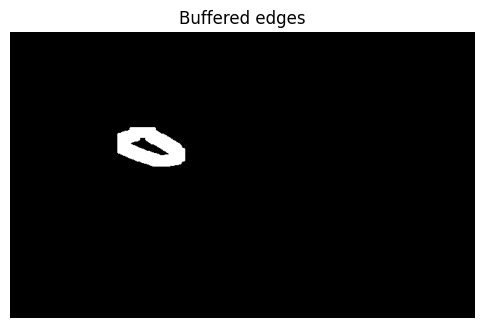

In [110]:
# Step 3: Buffer edges and visualize
buf = buffer_edges(edges_bin, buffer_px)
print('Buffered edges nonzero:', int((buf>0).sum()))

fig, ax = plt.subplots(1, 1, figsize=(6,5))
ax.imshow(buf, cmap='gray'); ax.set_title('Buffered edges'); ax.axis('off')
plt.show()

ROI: (142, 126, 252, 196)


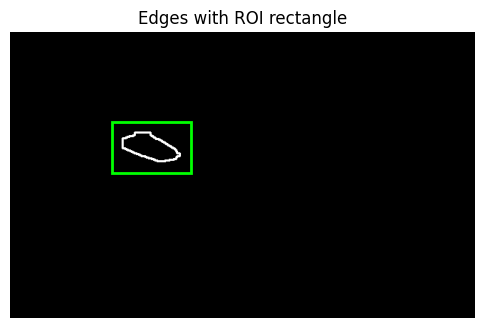

In [111]:
# Step 4: ROI from buffered mask
roi = compute_roi_from_mask(buf, roi_margin_px)
print('ROI:', roi)

# Visualize ROI rectangle on edges for context
fig, ax = plt.subplots(1, 1, figsize=(6,5))
ax.imshow(edges_bin, cmap='gray')
if roi is not None:
    x1, y1, x2, y2 = roi
    import matplotlib.patches as patches
    rect = patches.Rectangle((x1, y1), (x2-x1+1), (y2-y1+1), linewidth=2, edgecolor='lime', facecolor='none')
    ax.add_patch(rect)
    ax.set_title('Edges with ROI rectangle')
else:
    ax.set_title('Edges (no ROI found)')
ax.axis('off')
plt.show()

depth_roi shape: (71, 111) min: 0.0 max: 492.5426


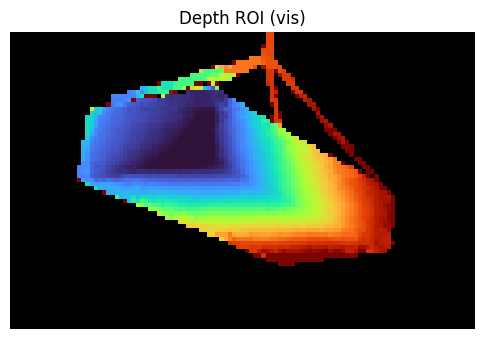

In [112]:
# Step 5: Clip depth to ROI and visualize
if roi is not None:
    x1, y1, x2, y2 = roi
    depth_roi = depth[y1:y2+1, x1:x2+1]
    print('depth_roi shape:', depth_roi.shape, 'min:', np.nanmin(depth_roi), 'max:', np.nanmax(depth_roi))
    depth_roi_vis = visualize_depth(depth_roi)
    plt.figure(figsize=(6,5))
    plt.imshow(depth_roi_vis[..., ::-1]); plt.title('Depth ROI (vis)'); plt.axis('off')
    plt.show()
else:
    print('No ROI – skipping depth ROI step.')

Gradient shape: (71, 111) min: 0.0 max: 255.0
Depth-edges nonzero: 387


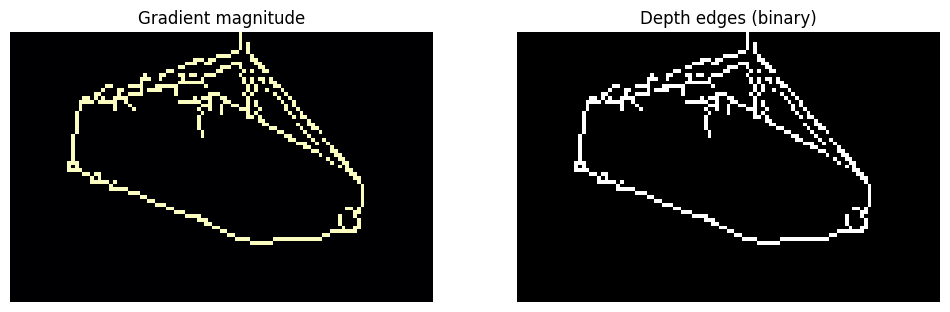

In [113]:
# Step 6: Detect depth edges inside ROI and visualize
if roi is not None:
    grad, depth_edges = detect_depth_edges(depth_roi, method, edge_thresh, edge_percentile)
    print('Gradient shape:', grad.shape, 'min:', float(np.min(grad)), 'max:', float(np.max(grad)))
    print('Depth-edges nonzero:', int((depth_edges>0).sum()))

    fig, axs = plt.subplots(1, 2, figsize=(12,5))
    axs[0].imshow(grad, cmap='magma'); axs[0].set_title('Gradient magnitude'); axs[0].axis('off')
    axs[1].imshow(depth_edges, cmap='gray'); axs[1].set_title('Depth edges (binary)'); axs[1].axis('off')
    plt.show()
else:
    print('No ROI – skipping edge detection step.')

Filtered depth edges with max distance 2.0px: kept 241 / 387


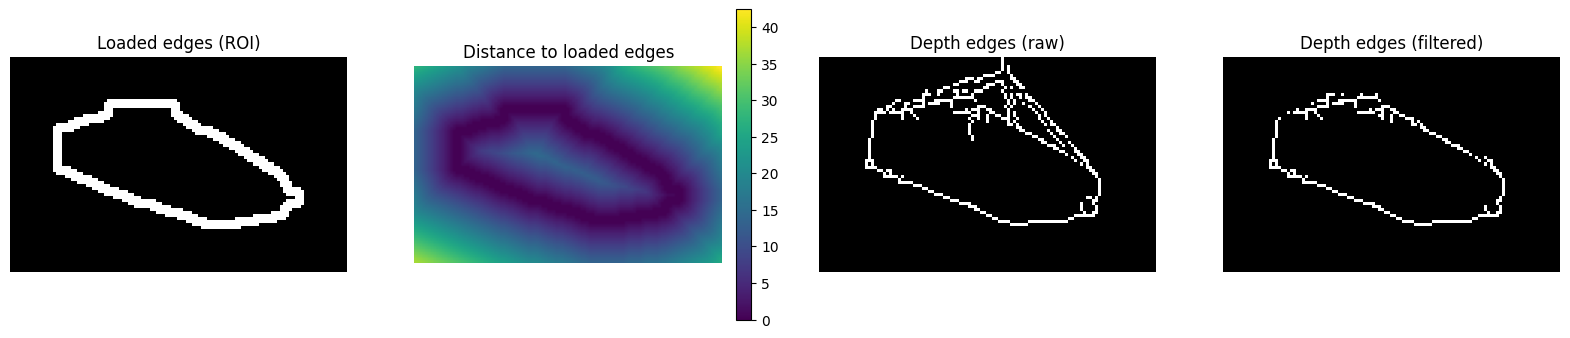

In [114]:
# Step 6.5: Filter depth edges by proximity to loaded edges (within ROI)
if roi is not None:
    # Extract loaded edges within ROI
    loaded_edges_roi = (edges_bin[y1:y2+1, x1:x2+1] > 0).astype(np.uint8)
    # Distance to nearest loaded edge (in pixels)
    # For distanceTransform, non-zero is foreground; distance is computed to nearest zero.
    # We want distance to the loaded edges => compute DT on the inverse mask (non-edge=1, edge=0)
    inv = (1 - loaded_edges_roi).astype(np.uint8) * 255
    dt = cv2.distanceTransform(inv, cv2.DIST_L2, 3)
    # Keep only depth-edge pixels that are close enough to any loaded edge
    max_d = float(max_edge_dist_px)
    valid = dt <= max_d
    depth_edges_filtered = ((depth_edges > 0) & valid).astype(np.uint8) * 255
    kept = int((depth_edges_filtered > 0).sum())
    total = int((depth_edges > 0).sum())
    print(f'Filtered depth edges with max distance {max_d}px: kept {kept} / {total}')

    # Visualize comparison
    fig, axs = plt.subplots(1, 4, figsize=(20,5))
    axs[0].imshow(loaded_edges_roi, cmap='gray'); axs[0].set_title('Loaded edges (ROI)'); axs[0].axis('off')
    im1 = axs[1].imshow(dt, cmap='viridis'); axs[1].set_title('Distance to loaded edges'); axs[1].axis('off')
    plt.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)
    axs[2].imshow(depth_edges, cmap='gray'); axs[2].set_title('Depth edges (raw)'); axs[2].axis('off')
    axs[3].imshow(depth_edges_filtered, cmap='gray'); axs[3].set_title('Depth edges (filtered)'); axs[3].axis('off')
    plt.show()
else:
    print('No ROI – skipping proximity filtering step.')

Candidate closed loops (interior regions): 0 (area >= 10 px)
Fallback (stroke-based) best loop: area = 133.0 perimeter = 146.5096663236618


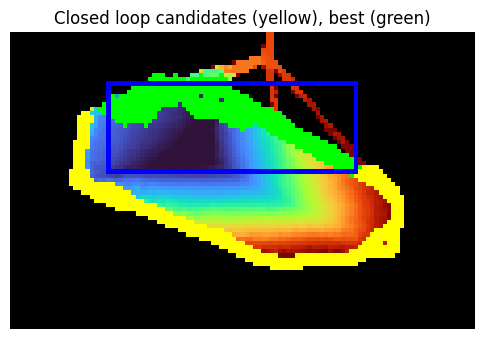

In [ ]:
# Step 7: Find closed loops in filtered depth edges
if roi is not None:
    # Binary mask from filtered depth edges within ROI
    mask = (depth_edges_filtered > 0).astype(np.uint8) * 255

    # Morphological closing to bridge small gaps and solidify loops
    k = max(1, int(round(buffer_px / 2)))
    ks = 2 * k + 1
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ks, ks))
    closed = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=1)

    # Find external contours as candidate closed loops
    cnts, hier = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Filter by minimum area to remove tiny fragments
    min_area = 100  # pixels; adjust if needed
    closed_loops = []
    for c in cnts:
        area = float(cv2.contourArea(c))
        if area < min_area:
            continue
        peri = float(cv2.arcLength(c, True))
        if peri <= 0:
            continue
        if len(c) < 4:
            continue
        closed_loops.append(c)

    print(f'Candidate closed loops: {len(closed_loops)} (area >= {min_area} px)')

    # Visualize: all candidates in yellow, best (largest area) in green with bbox
    vis = depth_roi_vis.copy()
    best_loop = None
    if closed_loops:
        cv2.drawContours(vis, closed_loops, -1, (0, 255, 255), 2)
        best_loop = max(closed_loops, key=cv2.contourArea)
        cv2.drawContours(vis, [best_loop], -1, (0, 255, 0), 3)
        bx, by, bw, bh = cv2.boundingRect(best_loop)
        cv2.rectangle(vis, (bx, by), (bx + bw, by + bh), (255, 0, 0), 1)
        print('Best loop: area =', float(cv2.contourArea(best_loop)), 'perimeter =', float(cv2.arcLength(best_loop, True)))
    else:
        print('No sufficiently large closed loops found.')

    plt.figure(figsize=(6,5))
    plt.imshow(vis[..., ::-1])
    plt.title('Closed loop candidates (yellow), best (green)')
    plt.axis('off')
    plt.show()
else:
    print('No ROI – skipping closed loop detection step.')

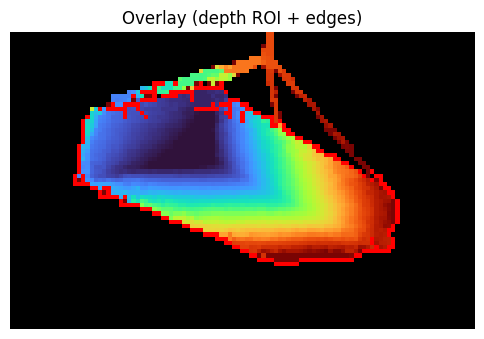

In [121]:
# Step 8: Overlay depth edges on depth ROI visualization
if roi is not None:
    overlay = depth_roi_vis.copy()
    cnts, _ = cv2.findContours((depth_edges_filtered > 0).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if cnts:
        cv2.drawContours(overlay, cnts, -1, (0,0,255), 1)
    plt.figure(figsize=(6,5))
    plt.imshow(overlay[..., ::-1]); plt.title('Overlay (depth ROI + edges)'); plt.axis('off')
    plt.show()
else:
    print('No ROI – skipping overlay step.')